# **Feature Detection and Texture Analysis using SIFT, ORB, LBP, and GLCM**


## **1. Import Required Libraries**

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import io, color
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

## **2. Load Images**

In [55]:
# Function to check if an image exists and load it
def load_image(image_path, as_gray=False):
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE if as_gray else cv2.IMREAD_COLOR)
    if image is None:
        print(f"Error: Unable to load the image at {image_path}. Check file format and integrity.")
    return image

# Define image paths
image1_path = r"C:\Users\Sreek\OneDrive\Desktop\New folder (2)\photo-1.jpg"
image2_path = r"C:\Users\Sreek\OneDrive\Desktop\New folder (2)\photo.jpg"
texture_path = r"C:\Users\Sreek\OneDrive\Desktop\WEEK-5 GRADED\WEEK-5 GRADED\images\fabric_texture.jpg"

# Load images
image1 = load_image(image1_path)
image2 = load_image(image2_path)
texture_image = load_image(texture_path, as_gray=True)

## **3. SIFT & ORB Keypoint Detection**

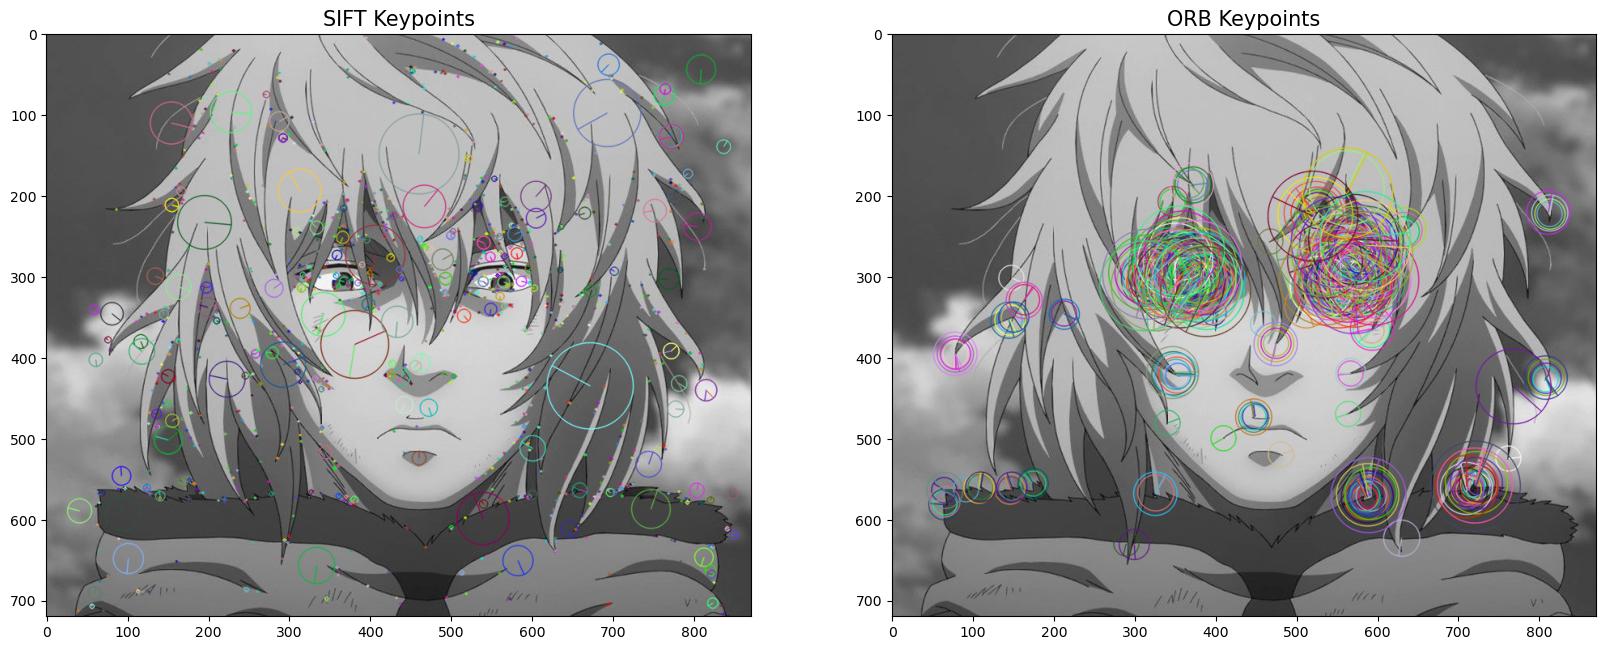

In [57]:
if image1 is not None and image2 is not None:
    gray_image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray_image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
# ----------------------- SIFT Keypoint Detection -----------------------
#SIFT (Scale-Invariant Feature Transform)
sift = cv2.SIFT_create()
keypoints_sift1, descriptors_sift1 = sift.detectAndCompute(gray_image1, None)
keypoints_sift2, descriptors_sift2 = sift.detectAndCompute(gray_image1, None)
sift_image1 = cv2.drawKeypoints(gray_image1, keypoints_sift1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# ----------------------- ORB Keypoint Detection -----------------------
#ORB (Oriented FAST and Rotated BRIEF)
orb = cv2.ORB_create()
keypoints_orb1, descriptors_orb1 = orb.detectAndCompute(gray_image1, None)
keypoints_orb2, descriptors_orb2 = orb.detectAndCompute(gray_image1, None)
orb_image1 = cv2.drawKeypoints(gray_image1, keypoints_orb1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display SIFT and ORB keypoints
plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1), plt.imshow(sift_image1, cmap='gray'), plt.title("SIFT Keypoints", fontsize=15)
plt.subplot(1, 2, 2), plt.imshow(orb_image1, cmap='gray'), plt.title("ORB Keypoints", fontsize=15)
plt.show()

#This section is crucial for tasks like image matching, object recognition, and image stitching.

## **4. Feature Matching (SIFT vs ORB)**

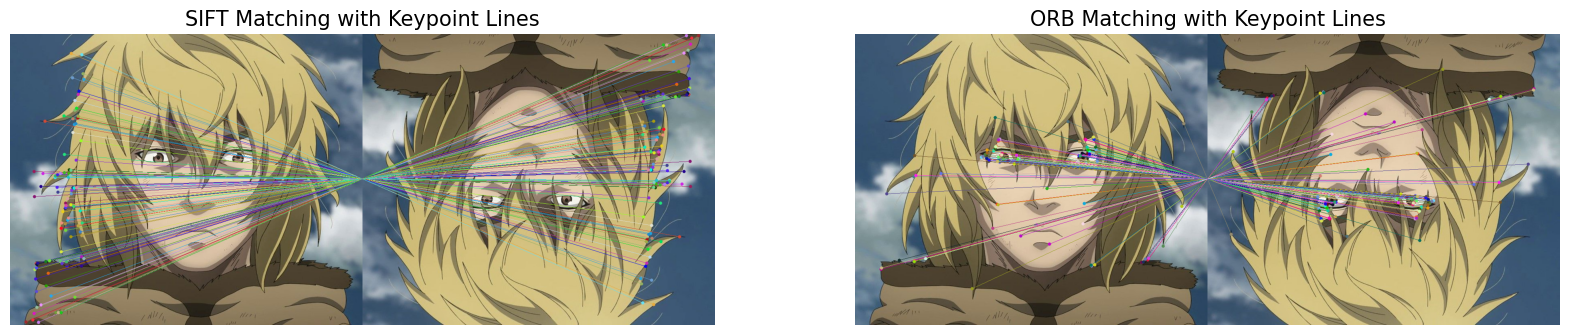

In [59]:
def draw_matches_with_lines(img1, keypoints1, img2, keypoints2, matches, title="Feature Matching"):
    """ Draws feature matches with lines between corresponding keypoints. """
    # Get image dimensions
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Create a blank canvas large enough for both images side by side
    match_canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    match_canvas[:h1, :w1] = img1
    match_canvas[:h2, w1:] = img2

    # Draw lines between matching points
    for m in matches:
        pt1 = tuple(map(int, keypoints1[m.queryIdx].pt))
        pt2 = tuple(map(int, keypoints2[m.trainIdx].pt))
        pt2 = (pt2[0] + w1, pt2[1])  # Adjust for concatenated image

        color = tuple(np.random.randint(0, 255, 3).tolist())  # Random color
        cv2.line(match_canvas, pt1, pt2, color, 1)
        cv2.circle(match_canvas, pt1, 4, color, -1)
        cv2.circle(match_canvas, pt2, 4, color, -1)

    return match_canvas

# Create a SIFT and ORB detector for keypoint detection and feature extraction in image processing.
sift = cv2.SIFT_create()
orb = cv2.ORB_create()

# Detect keypoints and compute descriptors
#This section detects keypoints and computes descriptors 
#for two grayscale images (gray_image1 and gray_image2) using SIFT and ORB feature detectors.
keypoints_sift1, descriptors_sift1 = sift.detectAndCompute(gray_image1, None)
keypoints_sift2, descriptors_sift2 = sift.detectAndCompute(gray_image2, None)

keypoints_orb1, descriptors_orb1 = orb.detectAndCompute(gray_image1, None)
keypoints_orb2, descriptors_orb2 = orb.detectAndCompute(gray_image2, None)

# Brute-Force Matcher for SIFT (with Lowe’s Ratio Test)
#This section matches keypoints detected in two images using Brute-Force Matching (BFMatcher) and applies the ratio test to filter out poor matches. 
#The process is specifically applied to SIFT descriptors. This step is crucial for robust feature-based image matching, used in applications like image stitching, 3D reconstruction, and object recognition.
bf = cv2.BFMatcher()
matches_sift = bf.knnMatch(descriptors_sift1, descriptors_sift2, k=2)
good_matches_sift = [m for m, n in matches_sift if m.distance < 0.7 * n.distance]  # Adjusted ratio test

# Brute-Force Matcher for ORB
# Cross-checking improves matching accuracy by ensuring mutual matches.
# Sorting by distance helps in selecting the best matches for further processing.
# This step is important for applications like image recognition, tracking, and object detection. 
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = sorted(bf_orb.match(descriptors_orb1, descriptors_orb2), key=lambda x: x.distance)

# Draw matches with lines for better visualization
sift_match_image = draw_matches_with_lines(image1, keypoints_sift1, image2, keypoints_sift2, good_matches_sift[:100], "SIFT Matches")
orb_match_image = draw_matches_with_lines(image1, keypoints_orb1, image2, keypoints_orb2, matches_orb[:100], "ORB Matches")

# Display results
plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sift_match_image, cv2.COLOR_BGR2RGB))
plt.title("SIFT Matching with Keypoint Lines", fontsize=15)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(orb_match_image, cv2.COLOR_BGR2RGB))
plt.title("ORB Matching with Keypoint Lines", fontsize=15), 
plt.axis("off")

plt.show()

## **5. Texture Analysis (GLCM & LBP)**

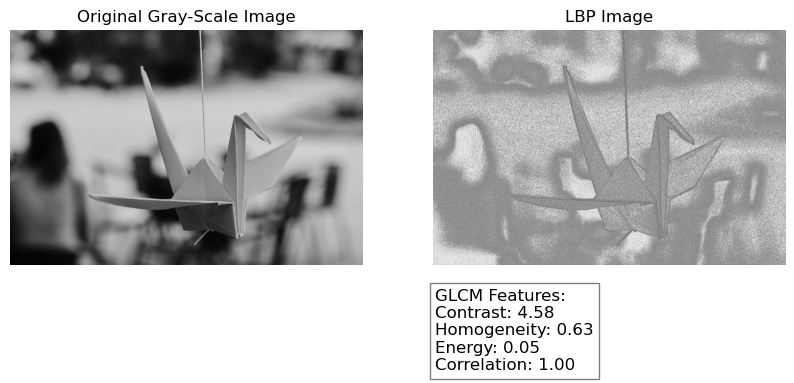

In [61]:
if texture_image is not None:
    lbp_radius = 1
    lbp_n_points = 8 * lbp_radius
    lbp = local_binary_pattern(texture_image, lbp_n_points, lbp_radius, method='uniform')

    glcm = graycomatrix((texture_image * 255).astype(np.uint8), distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    # Display the original image and LBP image
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(texture_image, cv2.COLOR_BGR2RGB))
    plt.title("Original Gray-Scale Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(lbp, cmap='gray')
    plt.title("LBP Image")
    plt.axis("off")

    # Adding text for GLCM features
    plt.gcf().text(0.55, 0.05, f"GLCM Features:\nContrast: {contrast:.2f}\nHomogeneity: {homogeneity:.2f}\nEnergy: {energy:.2f}\nCorrelation: {correlation:.2f}", 
                   fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    plt.show()

else:
    print(f"Error: Texture image not found at {texture_path}")